<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/FacialExpressionRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Recognition Attempt 1


In [ ]:
import cv2
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
face_cascade = cv2.CascadeClassifier('/content/drive/My Drive/haarcascade_frontalface_default.xml')

In [ ]:
from genericpath import isdir
def load_and_detect_faces(folder_path):
  images = []
  labels = []
  for label in os.listdir(folder_path):
    label_path = os.path.join(folder_path, label)
    if os.path.isdir(label_path):
      for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
          faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
          for (x, y, w, h) in faces:
            face_region = img[y:y+h, x:x+w]
            images.append(face_region)
            labels.append(label)
  return images, labels


In [ ]:
train_folder_path = '/content/drive/My Drive/CK_dataset/train'
test_folder_path = '/content/drive/My Drive/CK_dataset/test'

X_train, y_train = load_and_detect_faces(train_folder_path)
X_test, y_test = load_and_detect_faces(test_folder_path)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def preprocessimages(images):
    preprocessed_images = []
    for img in images:
      img = cv2.equalizeHist(img)
      preprocessed_images.append(img)
    return preprocessed_images

In [ ]:
radius = 1
n_points = 8 * radius


def extract_lbp_features(images):
  lbp_features = []
  for img in images:
    #resize the face image to standard size (if needed)
    img = cv2.resize(img, (64, 64))
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    #histogran of LBP patterns
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    # Normalise the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    lbp_features.append(hist)
  return np.array(lbp_features)

In [ ]:
# Extract LBP features
X_train_features = extract_lbp_features(X_train)
X_test_features = extract_lbp_features(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create an SVM pipeline with scaling and RBF kernel
svm_classifier = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=7.0, gamma='scale'))

# Train the SVM classifier
svm_classifier.fit(X_train_features, y_train)
y_pred = svm_classifier.predict(X_test_features)

# Train the classifier on the training features
svm_classifier.fit(X_train_features, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC(C=7.0))])

In [ ]:
# Predict the labels for the test features
y_pred = svm_classifier.predict(X_test_features)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:, {accuracy * 100:.2f}%")

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(len(y_test))
print(conf_matrix)

Accuracy:, 39.16%
143
[[ 5  0  7  5  1  0]
 [ 1  0  0  4  2  0]
 [ 2  0 13  7  0  8]
 [ 3  0  3 18  1 11]
 [ 1  0  4  4  5  3]
 [ 2  0  6 11  1 15]]


In [ ]:
import cv2
import numpy as np
import matplotlib. pyplot as plt
from skimage. feature import local_binary_pattern
#Define parameters for LBP
radius = 1
n_points = 8 * radius
# Load the Haar Cascade classifier for face detection
face_cascade = cv2.CascadeClassifier('/content/drive/My Drive/haarcascade_frontalface_default.xml')
# Function to preprocess and extract LBP features from a face image
def preprocess_and_extract_features (face_img):
# Resize the face image to a standard size
  face_img = cv2.resize(face_img, (64, 64))
#Apply LBP
  lbp = local_binary_pattern(face_img, n_points, radius, method="uniform")
#Compute the histogram of LBP patterns
  (hist,_) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range= (0, n_points + 2))
#Normalize the histogram
  hist = hist.astype("float")
  hist /= (hist.sum() + 1e-6)
  return hist.reshape(1, -1) # Return as a 2D array for model input

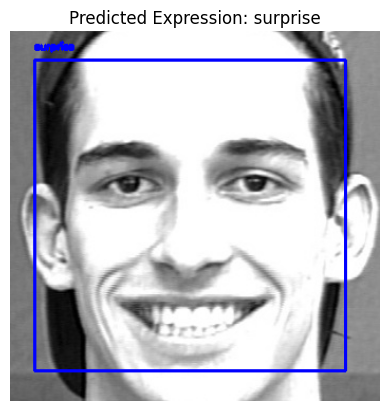

In [ ]:
def predict_emotion (image_path, model):
# Load the image in color
  img = cv2.imread (image_path)
  if img is None:
    raise ValueError("Image not found or could not be loaded.")
# Convert the image to grayscale for face detection
  gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Detect faces in the image
  faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
# If no faces are detected, return
  if len (faces) == 0:
    print("No faces detected in the image.")
    return
# Loop over the detected faces
  for (X, y, W, h) in faces:
    face_region = gray_img[y:y+h, X:X+W] # Crop the detected face region
# Extract features from the face region
    features = preprocess_and_extract_features (face_region)
# Predict the expression (directly get the predicted label as a string)
    predicted_expression = model.predict (features) [0]
# Draw a rectangle around the face
    cv2.rectangle(img, (X, y), (X+W, y+h), (255, 0, 0), 2) # Red rectangle
# Display the predicted label above the rectangle
    cv2.putText (img, predicted_expression, (X, y - 10), cv2. FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 2)
# Convert to RGB for display
    img_rgb = cv2.cvtColor(img, cv2. COLOR_BGR2RGB)
# Display the image with predictions
    plt.imshow(img_rgb)
    plt.title(f"Predicted Expression: {predicted_expression}")
    plt.axis('off')
    plt.show()
# Example path to an image
image_path = "/content/drive/My Drive/CK_dataset/test/happy/21.jpg"
predict_emotion (image_path, svm_classifier)